# BS202 Guided Practice 1

In [1]:
#@title Setup
import numpy as np
import matplotlib.pyplot as plt
from math import comb, exp, lgamma, log

def binomial_pmf(x, n, p):
    return comb(n, x) * p**x * (1-p)**(n-x) if 0 <= x <= n else 0.0

def neg_binomial_pmf(y, r, p):
    return comb(y-1, r-1) * p**r * (1-p)**(y-r) if y >= r else 0.0

def hypergeometric_pmf(x, N, K, n):
    return comb(K, x) * comb(N-K, n-x) / comb(N, n) if max(0, n-N+K) <= x <= min(K, n) else 0.0

def neg_hypergeometric_pmf(y, N, K, r):
    return comb(y-1, r-1) * comb(N-y, K-r) / comb(N, K) if r <= y <= N-K+r else 0.0

def poisson_pmf(x, mean):
    return exp(-mean + x*log(mean) - lgamma(x+1)) if x >= 0 and mean > 0 else float(x == 0)

def gamma_pdf(t, r, rate):
    return exp(r*log(rate) + (r-1)*log(t) - rate*t - lgamma(r)) if t > 0 else 0.0

def seat_open_probability(t, seats, rate):
    return sum(poisson_pmf(k, rate*t) for k in range(seats))

def posterior(prevalence, sensitivity, specificity, result='positive'):
    if result == 'positive':
        a, b = prevalence*sensitivity, (1-prevalence)*(1-specificity)
    else:
        a, b = prevalence*(1-sensitivity), (1-prevalence)*specificity
    return a/(a+b)

sample_cache = {}
def get_sample(name, settings, seed, build):
    key = (name, tuple(settings), seed)
    if key not in sample_cache:
        sample_cache[key] = build(np.random.default_rng(seed))
    return sample_cache[key]

def measure(seq, n, r):
    X = seq[:, :n].sum(axis=1)
    reached = np.cumsum(seq, axis=1) >= r
    return X, reached.argmax(axis=1)+1

def histogram_with_pmf(ax, values, pmf, xmax, mean=None, label='pmf'):
    xs = np.arange(xmax+1)
    freq = np.array([(values == x).mean() for x in xs])
    ax.bar(xs, freq, width=0.8, color='#c5cfe6', label='simulated')
    ax.plot(xs, [pmf(int(x)) for x in xs], 'o', color='#003bd1', ms=4, label=label)
    if mean is not None:
        ax.axvline(mean, color='k', ls='--', lw=1, label='mean')
    ax.set(xlim=(-0.6, xmax+0.6), ylabel='fraction')
    tail = (values > xmax).mean()
    if tail:
        ax.text(.98, .93, f'{tail:.1%} beyond', transform=ax.transAxes, ha='right', va='top', fontsize=8)

def build_arrivals(rng, rate, seats, runs=10000, horizon=60.0):
    # millisecond slots, request probability rate/1000 in each: gaps are geometric.
    # Every stream extends past the horizon and past its own seats-th request.
    slots = 1000
    columns = max(seats, int(rate*horizon + 4*np.sqrt(rate*horizon) + 20))
    arrival_slots = rng.geometric(rate/slots, size=(runs, columns)).cumsum(axis=1)
    while np.any(arrival_slots[:, -1] <= horizon*slots):
        extra = arrival_slots[:, -1, None] + rng.geometric(rate/slots, size=(runs, 32)).cumsum(axis=1)
        arrival_slots = np.concatenate((arrival_slots, extra), axis=1)
    return arrival_slots, horizon

def population_grid(ax, groups, per_square, N=50, first_width=None):
    """groups: list of (count, colour, label). The first two fill a block in the top-left
    corner; the rest fill the remaining cells in reading order. One square = per_square people."""
    q = [int(round(n / per_square)) for n, _, _ in groups]
    w = first_width or max(1, int(np.ceil((q[0] + q[1]) / N))); h = int(np.ceil((q[0] + q[1]) / w))
    colours = np.full((N, N), '', dtype='<U7')
    for k, (r, c) in enumerate([(r, c) for r in range(h) for c in range(w)][:q[0] + q[1]]):
        colours[r, c] = groups[0][1] if k < q[0] else groups[1][1]
    rest = [(r, c) for r in range(N) for c in range(N) if colours[r, c] == '']
    for k, (r, c) in enumerate(rest):
        colours[r, c] = groups[2][1] if k < q[2] else groups[3][1]
    rr, cc = np.divmod(np.arange(N * N), N)
    ax.scatter(cc, -rr, c=list(colours.ravel()), s=36, marker='s', linewidths=0)
    for i, (n, colour, label) in enumerate(groups):
        ax.text(N + 1.5, -3 - 3 * i, f'{n:,}  {label}', color=colour, fontsize=12, va='center')
    ax.set(xlim=(-1, N + 24), ylim=(-N - 5, 1)); ax.set_aspect('equal'); ax.set_axis_off()

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('ready')


ready


## Question 1

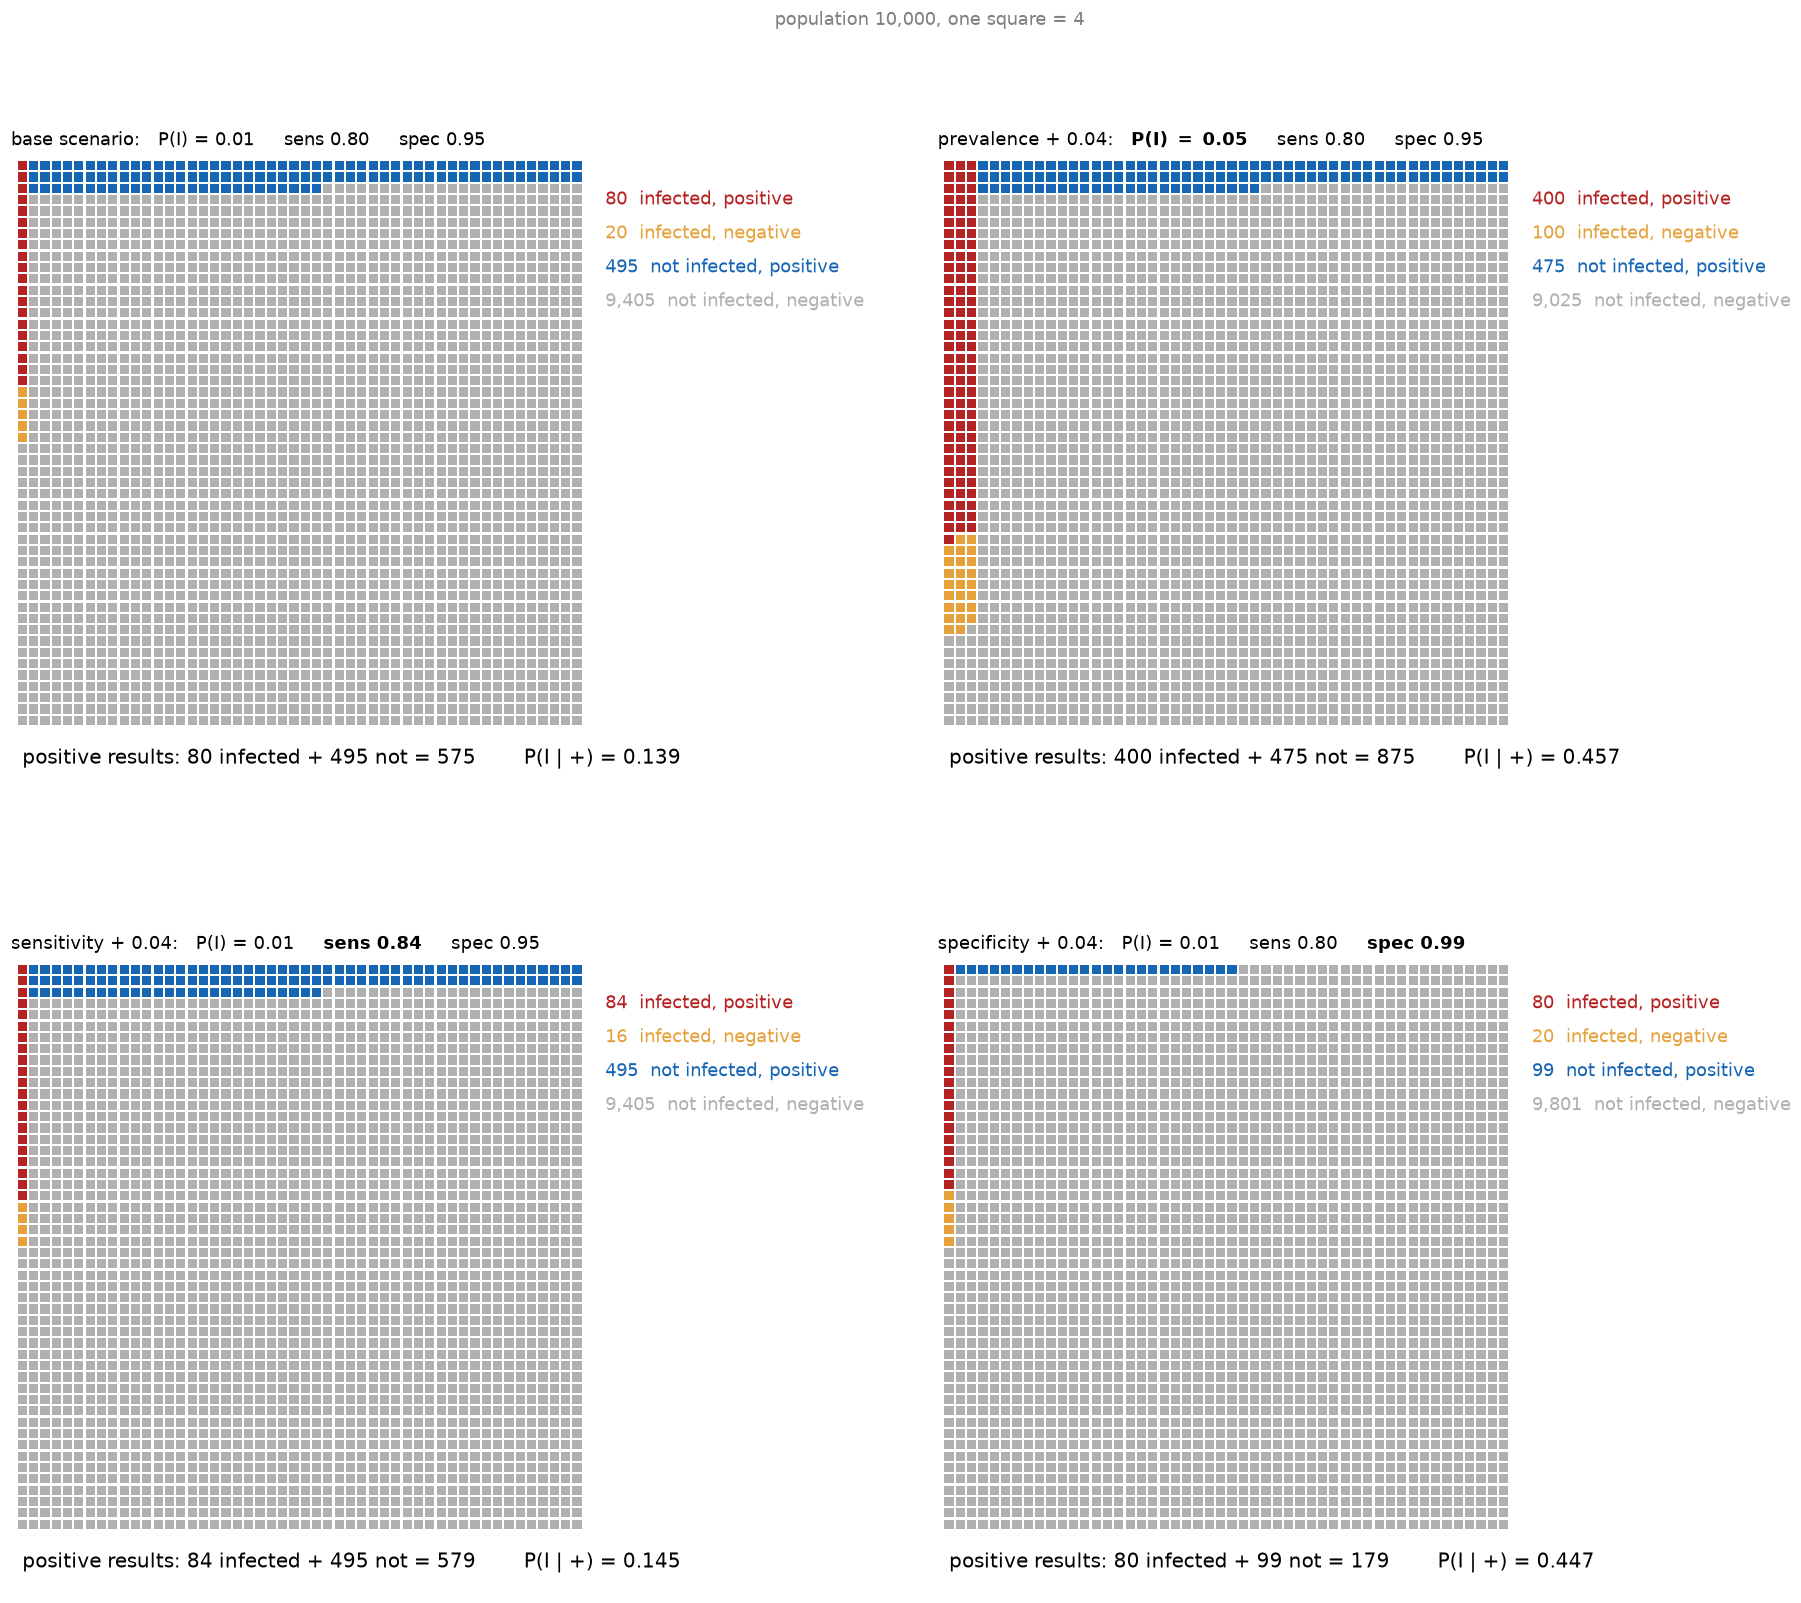

                   P(I)   sens   spec     TP     FP  P(I|+) counts    exact
base scenario     0.010   0.80  0.950     80    495          0.139   0.1391
prevalence        0.050   0.80  0.950    400    475          0.457   0.4571
sensitivity       0.010   0.84  0.950     84    495          0.145   0.1451
specificity       0.010   0.80  0.990     80     99          0.447   0.4469


In [2]:
#@title Cell 1
population = 10000  #@param {type:"number"}
prevalence = 0.01  #@param {type:"number"}
sensitivity = 0.80  #@param {type:"number"}
specificity = 0.95  #@param {type:"number"}
step = 0.04  #@param {type:"number"}
N = 50
population = int(population); per_square = population / N**2      # the grid never changes
base = dict(prevalence=prevalence, sensitivity=sensitivity, specificity=specificity)
red, orange, blue, grey = '#b52222', '#e5a23b', '#1766b5', '#b0b0b0'
results = {}
fig, axes = plt.subplots(2, 2, figsize=(17, 16))
for ax, changed in zip(axes.flat, [None, 'prevalence', 'sensitivity', 'specificity']):
    s = dict(base)
    if changed:
        s[changed] = min(1, s[changed] + step)
    n_inf = s['prevalence'] * population
    tp, fn = round(n_inf * s['sensitivity']), round(n_inf * (1 - s['sensitivity']))
    fp = round((population - n_inf) * (1 - s['specificity'])); tn = population - tp - fn - fp
    results[changed or 'base scenario'] = (s, tp, fn, fp, tn)
    population_grid(ax, [(tp, red, 'infected, positive'), (fn, orange, 'infected, negative'),
                         (fp, blue, 'not infected, positive'), (tn, grey, 'not infected, negative')], per_square)
    parts = [(f'P(I) = {s["prevalence"]:g}', 'prevalence'), (f'sens {s["sensitivity"]:.2f}', 'sensitivity'), (f'spec {s["specificity"]:.3g}', 'specificity')]
    title = '     '.join(('$\\bf{' + t.replace(' ', '\\ ') + '}$') if name == changed else t for t, name in parts)
    ax.set_title(('base scenario:   ' if not changed else f'{changed} + {step:g}:   ') + title, fontsize=12, loc='left')
    ax.text(0, -N - 1.5, f'positive results: {tp:,} infected + {fp:,} not = {tp + fp:,}        P(I | +) = {tp / (tp + fp):.3f}', fontsize=13, va='top')
fig.suptitle(f'population {population:,}, one square = {per_square:g}', fontsize=12, color='grey')
plt.tight_layout(); plt.show()
print(f'{"":16s}{"P(I)":>7s}{"sens":>7s}{"spec":>7s}{"TP":>7s}{"FP":>7s}{"P(I|+) counts":>15s}{"exact":>9s}')
for key, (s, tp, fn, fp, tn) in results.items():
    print(f'{key:16s}{s["prevalence"]:7.3f}{s["sensitivity"]:7.2f}{s["specificity"]:7.3f}{tp:7d}{fp:7d}{tp/(tp+fp):15.3f}{posterior(s["prevalence"], s["sensitivity"], s["specificity"]):9.4f}')


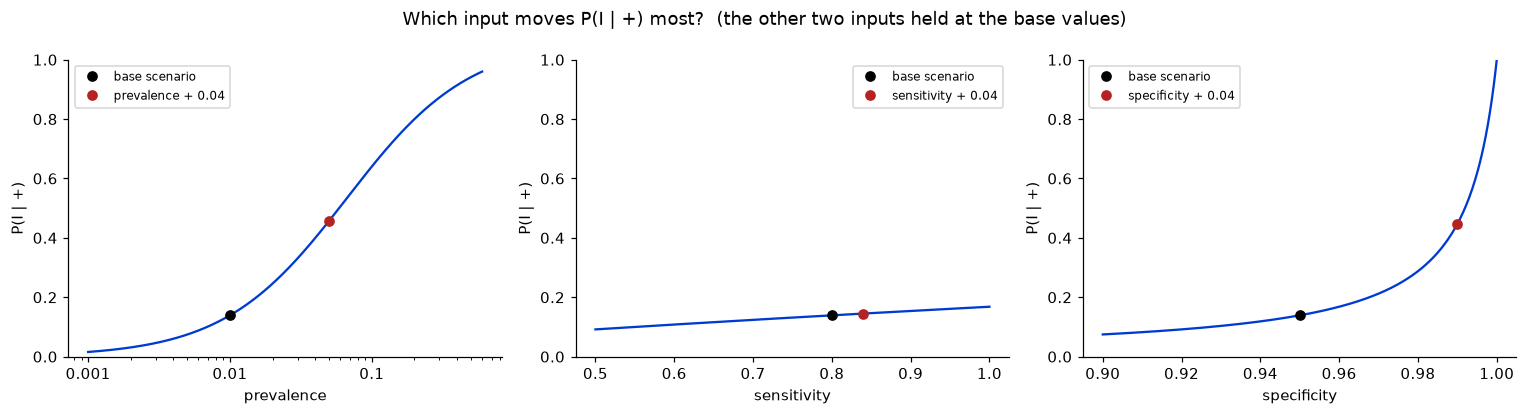

In [3]:
#@title Cell 2
prevalence = 0.01  #@param {type:"number"}
sensitivity = 0.80  #@param {type:"number"}
specificity = 0.95  #@param {type:"number"}
step = 0.04  #@param {type:"number"}
base = dict(prevalence=prevalence, sensitivity=sensitivity, specificity=specificity)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
grids = [('prevalence', np.logspace(-3, np.log10(.6), 400)), ('sensitivity', np.linspace(.5, 1, 400)), ('specificity', np.linspace(.90, 1, 400))]
for ax, (name, grid) in zip(axes, grids):
    ax.plot(grid, [posterior(**{**base, name: v}) for v in grid], color='#003bd1')
    ax.plot([base[name]], [posterior(**base)], 'ko', label='base scenario')
    v = min(1, base[name] + step)
    ax.plot([v], [posterior(**{**base, name: v})], 'o', color='#b52222', label=f'{name} + {step:g}')
    ax.set(xlabel=name, ylim=(0, 1), ylabel='P(I | +)'); ax.legend(fontsize=8)
    if name == 'prevalence':
        ax.set_xscale('log'); ax.set_xticks([0.001, 0.01, 0.1]); ax.set_xticklabels(['0.001', '0.01', '0.1'])
fig.suptitle('Which input moves P(I | +) most?  (the other two inputs held at the base values)')
plt.tight_layout(); plt.show()


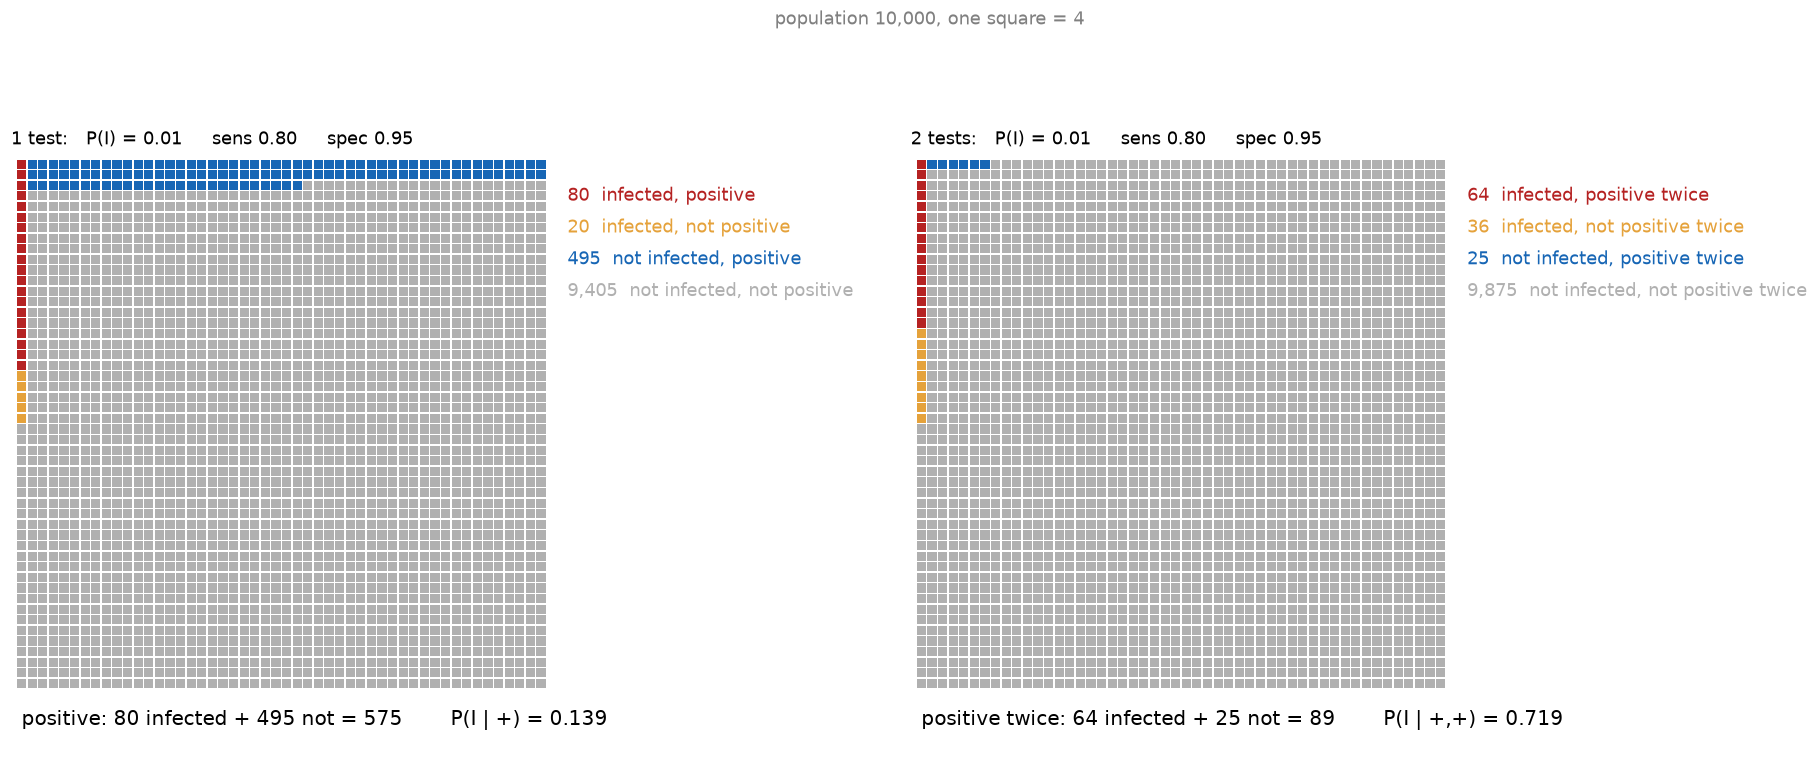

results     P(results | I)  P(results | not I) from the counts     exact
+                   0.8000            0.050000          0.1391    0.1391
++                  0.6400            0.002500          0.7191    0.7211
+-                  0.1600            0.047500          0.0329    0.0329
+++                 0.5120            0.000125          0.9808    0.9764


In [4]:
#@title Cell 3
population = 10000  #@param {type:"number"}
prevalence = 0.01  #@param {type:"number"}
sensitivity = 0.80  #@param {type:"number"}
specificity = 0.95  #@param {type:"number"}
N = 50
population = int(population); per_square = population / N**2
red, orange, blue, grey = '#b52222', '#e5a23b', '#1766b5', '#b0b0b0'
n_inf = round(prevalence * population); n_not = population - n_inf
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
for ax, tests in zip(axes, (1, 2)):
    tp = round(n_inf * sensitivity**tests); fp = round(n_not * (1 - specificity)**tests)
    word = 'positive' if tests == 1 else 'positive twice'
    population_grid(ax, [(tp, red, f'infected, {word}'), (n_inf - tp, orange, f'infected, not {word}'),
                         (fp, blue, f'not infected, {word}'), (n_not - fp, grey, f'not infected, not {word}')], per_square)
    ax.set_title(f'{tests} test{"s" if tests > 1 else ""}:   P(I) = {prevalence:g}     sens {sensitivity:.2f}     spec {specificity:.3g}', fontsize=12, loc='left')
    plus = '+' if tests == 1 else '+,+'
    ax.text(0, -N - 1.5, f'{word}: {tp:,} infected + {fp:,} not = {tp + fp:,}        P(I | {plus}) = {tp / (tp + fp):.3f}', fontsize=13, va='top')
fig.suptitle(f'population {population:,}, one square = {per_square:g}', fontsize=12, color='grey')
plt.tight_layout(); plt.show()
print(f'{"results":10s}{"P(results | I)":>16s}{"P(results | not I)":>20s}{"from the counts":>16s}{"exact":>10s}')
for results in ['+', '++', '+-', '+++']:
    a = np.prod([sensitivity if r == '+' else 1-sensitivity for r in results])
    b = np.prod([1-specificity if r == '+' else specificity for r in results])
    tp_, fp_ = round(n_inf*a), round(n_not*b)
    print(f'{results:10s}{a:16.4f}{b:20.6f}{tp_/(tp_+fp_) if tp_+fp_ else float("nan"):16.4f}{prevalence*a/(prevalence*a+(1-prevalence)*b):10.4f}')


## Question 2

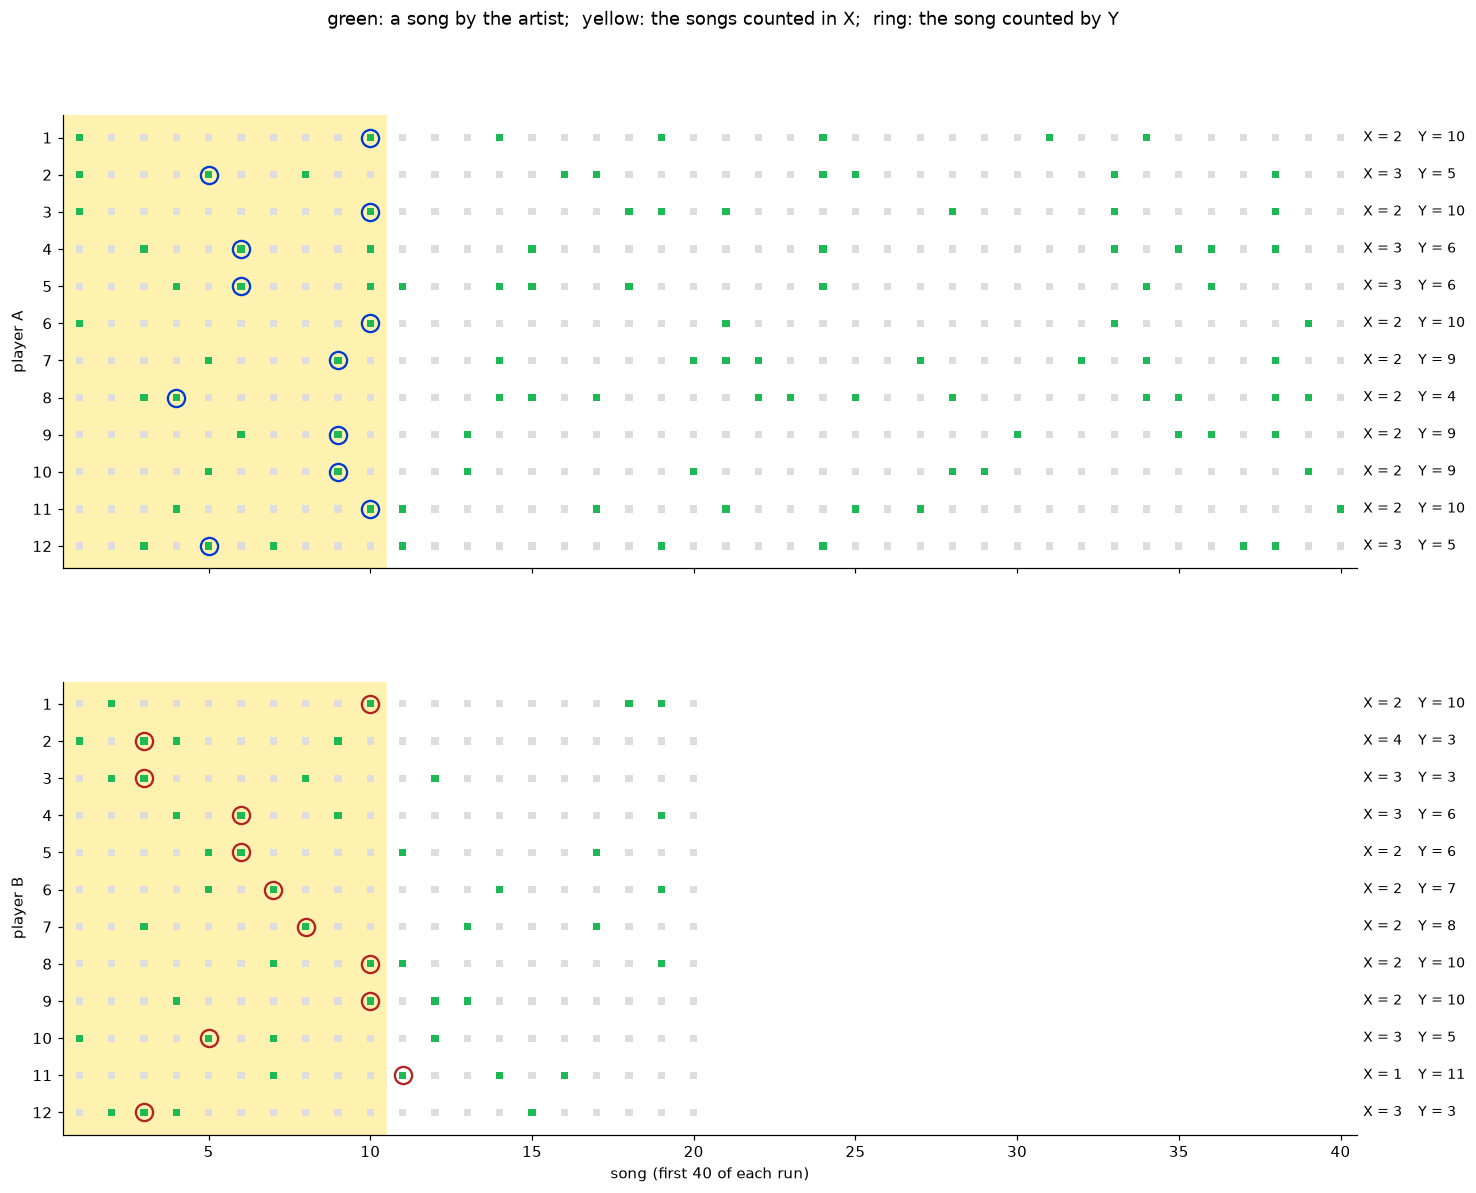

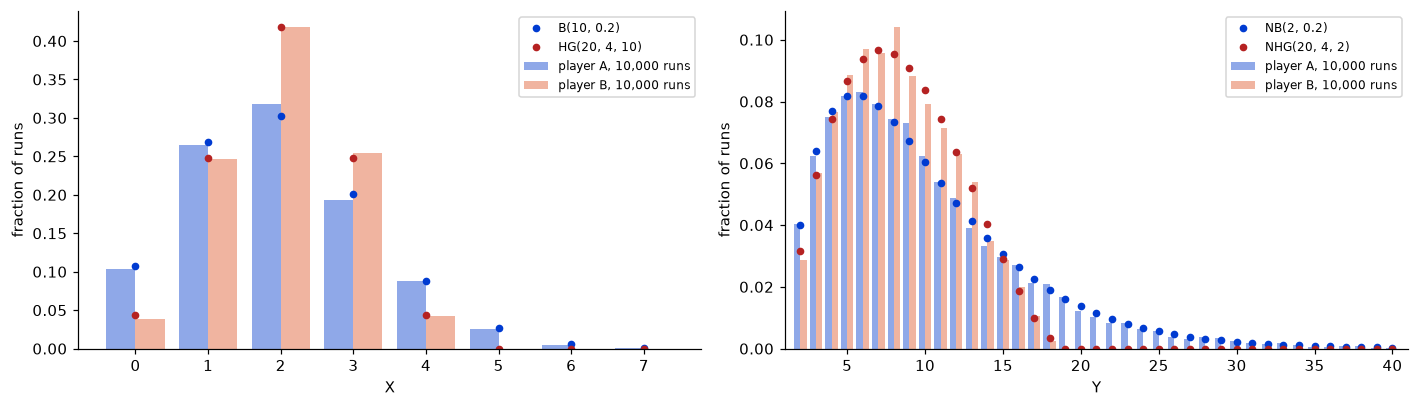

first 10,000 runs               mean X   var X  mean Y      X=0     X>=4     X>=2    Y<=10     Y>15
player A, simulated              2.001   1.566   9.946   0.1039   0.1201   0.6317   0.6317   0.1639
player A, exact                  2.000   1.600  10.000   0.1074   0.1209   0.6242   0.6242   0.1671
player B, simulated              2.016   0.822   8.355   0.0382   0.0420   0.7150   0.7150   0.0332
player B, exact                  2.000   0.842   8.400   0.0433   0.0433   0.7090   0.7090   0.0320
player A: sum of f(y) for y = 2 to 10, NB(2, 0.2): 0.6242

player B, run 1: probability that the next song is by the artist
song          1     2     3     4     5     6     7     8     9    10
artist        .     A     .     .     .     .     .     .     .     A
P(next)   0.200 0.211 0.167 0.176 0.188 0.200 0.214 0.231 0.250 0.273
player A: 0.200 before every song


In [5]:
#@title Cell 4
songs = 20  #@param {type:"number"}
by_artist = 4  #@param {type:"number"}
played = 10  #@param {type:"number"}
target = 2  #@param {type:"number"}
runs = 10000  #@param [10, 100, 10000] {type:"raw"}
seed = 2029  #@param {type:"integer"}
songs, by_artist, played, target, total = int(songs), int(by_artist), int(played), int(target), 10000
p = by_artist/songs
col = {1: ('#8fa8e8', '#003bd1'), 2: ('#f0b4a0', '#b52222')}
player_names = {1: 'player A', 2: 'player B'}
STRIP = max(40, int(np.ceil(1.5*played/10)*10))                 # songs drawn per run: the window and the usual Y
ROWS = 12

def build_runs(rng):
    seq_2 = rng.random((total, songs)).argsort(axis=1) < by_artist
    seq_1 = rng.random((total, 4*songs)) < p
    while np.any(seq_1.sum(axis=1) < target):
        seq_1 = np.concatenate((seq_1, rng.random((total, 2*songs)) < p), axis=1)
    return seq_1, seq_2

seq_1, seq_2 = get_sample('runs', (songs, by_artist, played, target, total), seed, build_runs)
X1, Y1 = measure(seq_1, played, target); X2, Y2 = measure(seq_2, played, target)
m = int(runs)
YMAX = int(np.ceil(np.quantile(np.concatenate([Y1, Y2]), .995) / 10) * 10)        # axis for Y follows the data
XLO, XHI = int(np.quantile(np.concatenate([X1, X2]), .001)), int(np.quantile(np.concatenate([X1, X2]), .999))
lo_x, hi_x = int(np.floor(played*p - 1.5*np.sqrt(played*p*(1-p)))), int(np.ceil(played*p + 1.5*np.sqrt(played*p*(1-p))))
tail_y = int(round((target/p + np.sqrt(target*(1-p))/p) / 5) * 5)          # one sd above the mean wait, rounded

# strips for both players
sq = max(4, min(22, int(2600/STRIP)))                             # square size follows the strip length
fig, axes = plt.subplots(2, 1, figsize=(16, 2*(0.42*ROWS+0.9)), sharex=True)
for ax, (method, seq) in zip(axes, [(1, seq_1), (2, seq_2)]):
    for row in range(ROWS):
        s_ = seq[row][:STRIP]
        X = int(seq[row][:played].sum()); Y = int(np.flatnonzero(seq[row])[target-1] + 1)
        ax.scatter(np.arange(1, len(s_)+1), np.full(len(s_), -row), s=sq, c=np.where(s_, '#1db954', '#dddddd'), marker='s', linewidths=0)
        if Y <= STRIP:
            ax.plot(Y, -row, 'o', mfc='none', mec=col[method][1], ms=max(6, sq**0.5*2.4), mew=1.5)
        ax.text(1.005, -row, f'X = {X:<4d} Y = {Y}', transform=ax.get_yaxis_transform(), va='center', fontsize=9)
    ax.axvspan(.5, min(played, STRIP)+.5, color='#fff2b0', zorder=0)
    ax.set(ylabel=player_names[method], xlim=(.5, STRIP+.5), ylim=(-ROWS+.4, .6))
    ax.set_yticks(-np.arange(ROWS), np.arange(1, ROWS+1))
axes[1].set_xlabel(f'song (first {STRIP} of each run)')
fig.suptitle('green: a song by the artist;  yellow: the songs counted in X;  ring: the song counted by Y')
fig.subplots_adjust(right=.86, top=.9, bottom=.12, hspace=.25); plt.show()

# many runs
exact = {1: (played*p, played*p*(1-p), target/p), 2: (played*p, played*p*(1-p)*(songs-played)/(songs-1), target*(songs+1)/(by_artist+1))}
pmfs = {1: (lambda x: binomial_pmf(x, played, p), lambda y: neg_binomial_pmf(y, target, p), f'B({played}, {p:g})', f'NB({target}, {p:g})'),
        2: (lambda x: hypergeometric_pmf(x, songs, by_artist, played), lambda y: neg_hypergeometric_pmf(y, songs, by_artist, target), f'HG({songs}, {by_artist}, {played})', f'NHG({songs}, {by_artist}, {target})')}

def paired(ax, data, xs, which):
    for k, (method, values) in enumerate(data):
        light, dark = col[method]
        freq = [(values[:m] == x).mean() for x in xs]
        ax.bar(xs+(k-.5)*.4, freq, width=.4, color=light, label=f'{player_names[method]}, {m:,} runs')
        ax.plot(xs, [pmfs[method][which](int(x)) for x in xs], 'o', color=dark, ms=4, label=pmfs[method][which+2])
    ax.set_ylabel('fraction of runs')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
xs = np.arange(max(0, XLO-1), min(played, XHI+1)+1)
paired(axes[0], [(1, X1), (2, X2)], xs, 0)
axes[0].set(xlabel='X'); axes[0].legend(fontsize=8)
ys = np.arange(target, YMAX+1)
paired(axes[1], [(1, Y1), (2, Y2)], ys, 1)
axes[1].set(xlabel='Y', xlim=(target-1, YMAX+1)); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
h = [('X=0' if lo_x == 0 else f'X<={lo_x}'), f'X>={hi_x}', f'X>={target}', f'Y<={played}', f'Y>{tail_y}']
print(f'{"first " + format(m, ",") + " runs":30s}{"mean X":>8s}{"var X":>8s}{"mean Y":>8s}' + ''.join(f'{k:>9s}' for k in h))
for method, X, Y in [(1, X1, Y1), (2, X2, Y2)]:
    EX, VX, EY = exact[method]; Xm, Ym = X[:m], Y[:m]; fx, fy = pmfs[method][0], pmfs[method][1]
    sim = [(Xm<=lo_x).mean(), (Xm>=hi_x).mean(), (Xm>=target).mean(), (Ym<=played).mean(), (Ym>tail_y).mean()]
    exa = [sum(fx(x) for x in range(0, lo_x+1)), sum(fx(x) for x in range(hi_x, played+1)), sum(fx(x) for x in range(target, played+1)),
           sum(fy(y) for y in range(target, played+1)), 1-sum(fy(y) for y in range(target, tail_y+1))]
    print(f'{player_names[method] + ", simulated":30s}{Xm.mean():8.3f}{Xm.var():8.3f}{Ym.mean():8.3f}' + ''.join(f'{v:9.4f}' for v in sim))
    print(f'{player_names[method] + ", exact":30s}{EX:8.3f}{VX:8.3f}{EY:8.3f}' + ''.join(f'{v:9.4f}' for v in exa))
print(f'player A: sum of f(y) for y = {target} to {played}, {pmfs[1][3]}: {sum(pmfs[1][1](y) for y in range(target, played+1)):.4f}')
print()
seq = seq_2[0][:played]
before = np.r_[0, np.cumsum(seq)[:-1]]
next_probabilities = (by_artist-before)/(songs-np.arange(played))
print('player B, run 1: probability that the next song is by the artist')
print('song      ' + ' '.join(f'{j:>5}' for j in range(1, played+1)))
print('artist    ' + ' '.join(f'{"A" if s_ else ".":>5}' for s_ in seq))
print('P(next)   ' + ' '.join(f'{q:5.3f}' for q in next_probabilities))
print(f'player A: {p:.3f} before every song')


   songs   var X, player A   exact B   var X, player B  exact HG
      20             1.611     1.600             0.831     0.842
      40             1.574     1.600             1.238     1.231
     200             1.569     1.600             1.485     1.528
    2000             1.620     1.600             1.612     1.593


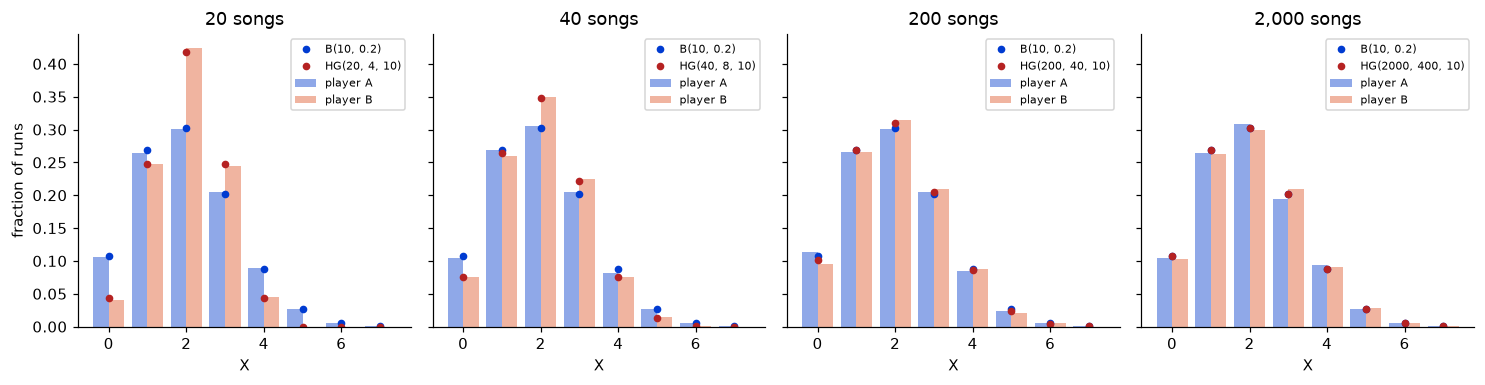

In [6]:
#@title Cell 5
lengths = "20, 40, 200, 2000"  #@param {type:"string"}
played = 10  #@param {type:"number"}
fraction_by_artist = 0.2  #@param {type:"number"}
seed = 2029  #@param {type:"integer"}
sizes = [int(v) for v in lengths.replace(';', ',').split(',') if v.strip()]
n, p, repeats = int(played), float(fraction_by_artist), 10000
col = {1: ('#8fa8e8', '#003bd1'), 2: ('#f0b4a0', '#b52222')}
player_names = {1: 'player A', 2: 'player B'}

def build_sizes(rng):
    return {N: (rng.binomial(n, p, size=repeats), rng.hypergeometric(round(N*p), N-round(N*p), n, size=repeats)) for N in sizes}

counts = get_sample('lengths', tuple(sizes)+(n, p, repeats), seed, build_sizes)
fig, axes = plt.subplots(1, len(sizes), figsize=(3.4*len(sizes), 3.6), sharey=True, squeeze=False)
allx = np.concatenate([v for pair in counts.values() for v in pair])
xs = np.arange(max(0, int(np.quantile(allx, .001))-1), min(n, int(np.quantile(allx, .999))+1)+1)
print(f'{"songs":>8s}{"var X, player A":>18s}{"exact B":>10s}{"var X, player B":>18s}{"exact HG":>10s}')
for ax, N in zip(axes[0], sizes):
    K = round(N*p)
    for k, (method, values, pmf, name) in enumerate([(1, counts[N][0], lambda x: binomial_pmf(x, n, p), f'B({n}, {p:g})'),
                                                     (2, counts[N][1], lambda x, N=N, K=K: hypergeometric_pmf(x, N, K, n), f'HG({N}, {K}, {n})')]):
        light, dark = col[method]
        ax.bar(xs+(k-.5)*.4, [(values == x).mean() for x in xs], width=.4, color=light, label=player_names[method])
        ax.plot(xs, [pmf(int(x)) for x in xs], 'o', color=dark, ms=4, label=name)
    ax.set(title=f'{N:,} songs', xlabel='X'); ax.legend(fontsize=7)
    print(f'{N:8d}{counts[N][0].var():18.3f}{n*p*(1-p):10.3f}{counts[N][1].var():18.3f}{n*p*(1-p)*(N-n)/(N-1):10.3f}')
axes[0][0].set_ylabel('fraction of runs')
plt.tight_layout(); plt.show()


## Question 3

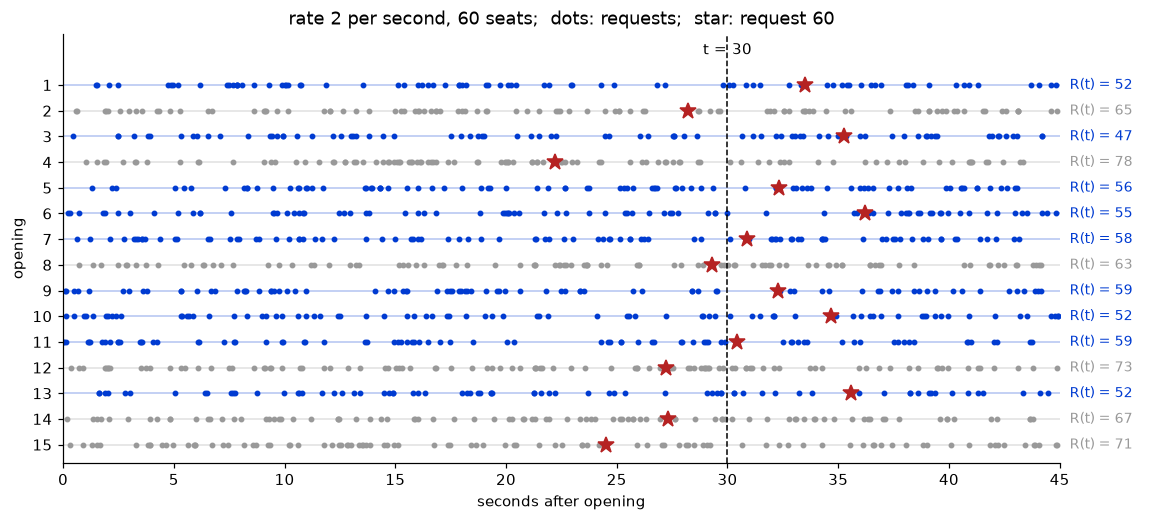

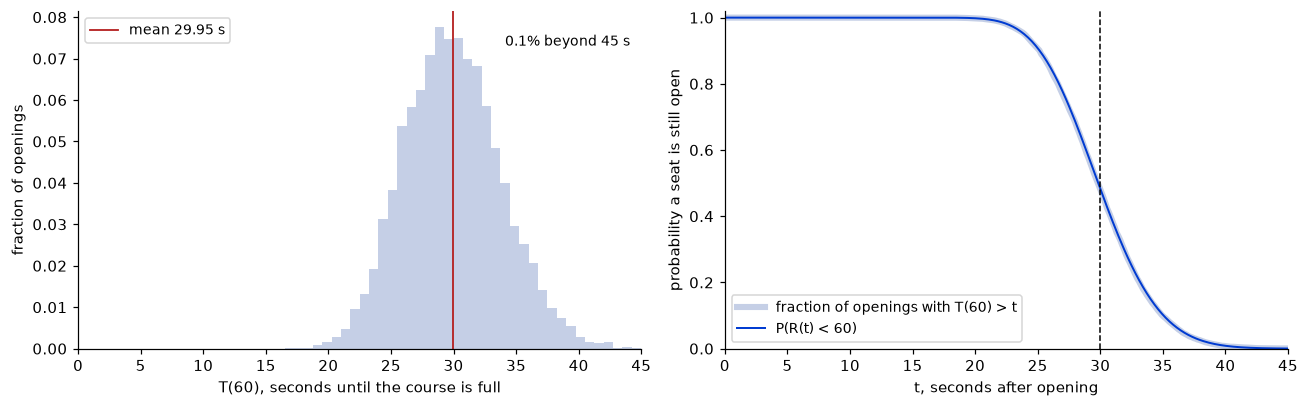

10,000 simulated openings, rate 2 per second, 60 seats
                                 simulated     exact
mean of T(60)                       29.949    30.000
standard deviation of T(60)          3.868
seat open at t = 20                 0.9978    0.9981
seat open at t = 30                 0.4807    0.4828
seat open at t = 40                 0.0075    0.0086


In [7]:
#@title Cell 6
rate = 2.0  #@param {type:"number"}
seats = 60  #@param {type:"number"}
time_cutoff = 30.0  #@param {type:"number"}
seed = 2029  #@param {type:"integer"}
seats = int(seats); t_cut = float(time_cutoff)
span = max(t_cut, 1.5*seats/rate)                                # the streams cover this much time
arrival_slots, horizon = get_sample('arrivals', (rate, seats, span), seed, lambda rng: build_arrivals(rng, rate, seats, horizon=span))
T = arrival_slots[:, seats-1]/1000
TMAX = float(np.ceil(max(t_cut*1.1, np.quantile(T, .999)) / 5) * 5)   # time axis follows the data, geometry does not
R_cut = (arrival_slots <= round(t_cut*1000)).sum(axis=1)
open_at_cut = R_cut < seats

fig, ax = plt.subplots(figsize=(12, 5))
for row in range(15):
    colour = '#003bd1' if open_at_cut[row] else '#999999'
    visible = arrival_slots[row]/1000; visible = visible[visible <= TMAX]
    ax.hlines(-row, 0, TMAX, color=colour, alpha=.3, lw=1)
    ax.scatter(visible, np.full(len(visible), -row), color=colour, s=8)
    if T[row] <= TMAX:
        ax.plot(T[row], -row, '*', color='#b52222', ms=11)
    ax.text(1.01, -row, f'R(t) = {R_cut[row]:<4d}', transform=ax.get_yaxis_transform(), va='center', fontsize=9, color=colour)
ax.axvline(t_cut, color='k', ls='--', lw=1)
ax.text(t_cut, 1.2, f't = {t_cut:g}', ha='center')
ax.set(yticks=-np.arange(15), yticklabels=np.arange(1, 16), xlabel='seconds after opening', ylabel='opening', xlim=(0, TMAX), ylim=(-14.7, 2))
ax.set_title(f'rate {rate:g} per second, {seats} seats;  dots: requests;  star: request {seats}')
fig.subplots_adjust(right=.88, top=.9, bottom=.12); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
bins = np.linspace(0, TMAX, 61)
axes[0].hist(T[T <= TMAX], bins=bins, weights=np.full((T <= TMAX).sum(), 1/len(T)), color='#c5cfe6')
axes[0].axvline(T.mean(), color='#b52222', lw=1.2, label=f'mean {T.mean():.2f} s')
if (T > TMAX).any():
    axes[0].text(.98, .93, f'{(T > TMAX).mean():.1%} beyond {TMAX:g} s', transform=axes[0].transAxes, ha='right', va='top', fontsize=9)
axes[0].set(xlabel=f'T({seats}), seconds until the course is full', ylabel='fraction of openings', xlim=(0, TMAX)); axes[0].legend(fontsize=9)
grid = np.linspace(0, TMAX, 300)
axes[1].plot(grid, [(T > t).mean() for t in grid], color='#c5cfe6', lw=4, label=f'fraction of openings with T({seats}) > t')
axes[1].plot(grid, [seat_open_probability(t, seats, rate) for t in grid], color='#003bd1', lw=1.3, label=f'P(R(t) < {seats})')
axes[1].axvline(t_cut, color='k', ls='--', lw=1)
axes[1].set(xlabel='t, seconds after opening', ylabel='probability a seat is still open', xlim=(0, TMAX), ylim=(0, 1.02)); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'{len(T):,} simulated openings, rate {rate:g} per second, {seats} seats')
print(f'{"":30s}{"simulated":>12s}{"exact":>10s}')
print(f'{"mean of T(" + str(seats) + ")":30s}{T.mean():12.3f}{seats/rate:10.3f}')
print(f'{"standard deviation of T(" + str(seats) + ")":30s}{T.std():12.3f}')
for t in sorted({t_cut, 20.0, 30.0, 40.0}):
    print(f'{"seat open at t = " + format(t, "g"):30s}{(T > t).mean():12.4f}{seat_open_probability(t, seats, rate):10.4f}')
